# Workbook 1 — Data Ingestion

fetches raw data from the **Statistics Denmark (DST) StatBank API** — a completely free, no-authentication data source licensed under CC 4.0 BY.

### Data that is being fetched
| Table | Content | Frequency |
|---|---|---|
| `KONK4` | Bankruptcies by industry, enterprise type | Monthly |
| `DEMO14` | New enterprise births by industry (Business Demography) | Annual |

### Artifact output
- `artifacts/raw/bankruptcies_latest.csv`
- `artifacts/raw/new_enterprises_latest.csv`


In [1]:
import sys
sys.path.insert(0, '..')  # allow importing from src/

import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from src.dst_client import DSTClient, fetch_bankruptcies, fetch_new_enterprises, save_raw

# Initialise the DST API client
client = DSTClient(language='en')
print("DST client ready — no credentials needed!")


DST client ready — no credentials needed!


## 1.1 Explore available tables
Before fetching data, the table schema is inspected using print_table_variables() to confirm the correct variable codes and available values.


In [2]:
#Explore bankruptcies table
print("\n== KONK4: Bankruptcies ==")
client.print_table_variables('KONK4')



== KONK4: Bankruptcies ==

Table: KONK4 — Bankruptcies
Unit: Number | Updated: 2026-01-07T08:00:00
Period:  → 

  Variable: BRANCHE — industry
             000  Bankruptcies, total
               1  Agriculture, forestry and fishing
               2  Manufacturing, mining and quarrying, and utility services
               3  Construction
               4  Trade and transport etc.
               G  Wholesale and retail trade
             G01  Sale and repair of motor vehicles
             G02  Wholesale trade
             G03  Retail trade
               H  Transportation
    ... (20 total values)

  Variable: VIRKTYP1 — type of enterprise
             K01  Declared bankruptcies, total
             K02  Declared bankruptcies in active companies
             K03  Declared bankruptcies in companies without emplyoees and turnover less than 1 mio. DKK.

  Variable: Tid — time
         2009M01  2009M01
         2009M02  2009M02
         2009M03  2009M03
         2009M04  2009M04
         20

In [3]:
info = client.get_table_info('DEMO14')
print(f"Table confirmed: {info['id']} — {info['text']}")

# Find the time variable by ID
time_var = next(
    (v for v in info['variables'] if v['id'] == 'Tid'),
    None
)
if time_var:
    periods = [x['id'] for x in time_var['values']]
    print(f"Period: {periods[0]} → {periods[-1]}")
else:
    print("Period: see variable list above")

print(f"Updated: {info.get('updated', 'N/A')}")

Table confirmed: DEMO14 — Business Demography
Period: 2019 → 2023
Updated: 2025-06-13T08:00:00


In [4]:
# Inspect the full variable schema for DEMO14
print("\nDEMO14: Business Demography, Enterprise Births")
try:
    client.print_table_variables('DEMO14')
except Exception as e:
    print(f"Table not found: {e}")


DEMO14: Business Demography, Enterprise Births

Table: DEMO14 — Business Demography
Unit: - | Updated: 2025-06-13T08:00:00
Period:  → 

  Variable: REGION — region
             000  All Denmark
             084  Region Hovedstaden
             085  Region Sjælland
             083  Region Syddanmark
             082  Region Midtjylland
             081  Region Nordjylland

  Variable: BRANCHEDB0710 — industry (DB07 10-grouping)
             TOT  TOT Industry total
               1  1 Agriculture, forestry and fishing
               2  2 Manufacturing, mining and quarrying, and utility services
               3  3 Construction
               4  4 Trade and transport etc.
               5  5 Information and communication
               6  6 Financial and insurance
               7  7 Real estate
               8  8 Other business services
               9  9 Public administration, education and health
    ... (12 total values)

  Variable: MÆNGDE4 — unit
             AFU  Employees (in 

## 1.2 Fetch bankruptcies data (KONK4)
ALL available periods and ALL industries are fetched


In [5]:
# Fetch full bankruptcy history
df_bankrupt = fetch_bankruptcies(client)

print(f"Shape: {df_bankrupt.shape}")
print(f"Date range: {df_bankrupt['period'].min()} → {df_bankrupt['period'].max()}")
print(f"\nSectors available:")
print(df_bankrupt['branche10'].unique())
print(f"\nFirst few rows:")
df_bankrupt.head(10)


2026-04-16 17:19:25,644 [INFO] Fetching table KONK4 ...
2026-04-16 17:19:28,428 [INFO]   → 4,080 rows fetched


Shape: (2040, 4)
Date range: 2009-01-01 00:00:00 → 2025-12-01 00:00:00

Sectors available:
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10']

First few rows:


,branche10,virktyp1,period,bankruptcies
0,1,K02,2009-01-01,2
1,1,K02,2009-02-01,6
2,1,K02,2009-03-01,6
3,1,K02,2009-04-01,5
4,1,K02,2009-05-01,3
5,1,K02,2009-06-01,5
6,1,K02,2009-07-01,3
7,1,K02,2009-08-01,4
8,1,K02,2009-09-01,4
9,1,K02,2009-10-01,7


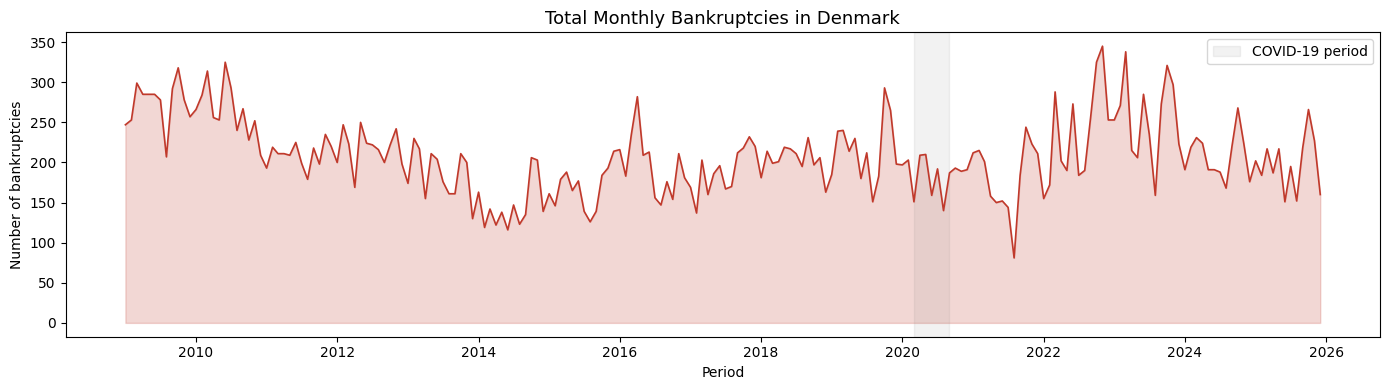

In [6]:
import matplotlib.pyplot as plt
import os

# Create artifact folders first
os.makedirs('../artifacts/reports', exist_ok=True)
os.makedirs('../artifacts/raw', exist_ok=True)
os.makedirs('../artifacts/processed', exist_ok=True)
os.makedirs('../artifacts/models', exist_ok=True)
os.makedirs('../artifacts/metrics', exist_ok=True)

# Quick sanity check: plot total bankruptcies over time
monthly_total = df_bankrupt.groupby('period')['bankruptcies'].sum()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly_total.index, monthly_total.values, linewidth=1.2, color='#c0392b')
ax.fill_between(monthly_total.index, monthly_total.values, alpha=0.2, color='#c0392b')
ax.set_title('Total Monthly Bankruptcies in Denmark', fontsize=13)
ax.set_xlabel('Period')
ax.set_ylabel('Number of bankruptcies')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-09-01'),
           alpha=0.1, color='grey', label='COVID-19 period')
ax.legend()
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_bankruptcies_timeseries.png', dpi=120)
plt.show()

## 1.3 Fetch new enterprise births (DEMO14)
DEMO14 is the Business Demography table for annual enterprise births by industry (DB07 10-grouping). It covers 2019–2023 and has an inherent ~2 year publication lag due to DST's verification process. Values are forward-filled to quarterly frequency in the next workbook.


In [7]:
info = client.get_table_info('DEMO14')
print("Variables:")
for v in info['variables']:
    print(f"  code='{v['id']}'  text='{v['text']}'")

Variables:
  code='REGION'  text='region'
  code='BRANCHEDB0710'  text='industry (DB07 10-grouping)'
  code='MÆNGDE4'  text='unit'
  code='Tid'  text='time'


In [8]:
# Check what DEMO14 expects, look at the types of entities and values it has
info = client.get_table_info('DEMO14')
for v in info['variables']:
    print(f"\nVariable ID: '{v['id']}'")
    print(f"  Values: {[x['id'] for x in v['values'][:5]]}")


Variable ID: 'REGION'
  Values: ['000', '084', '085', '083', '082']

Variable ID: 'BRANCHEDB0710'
  Values: ['TOT', '1', '2', '3', '4']

Variable ID: 'MÆNGDE4'
  Values: ['AFU', 'OPH', 'OMS', 'NYE']

Variable ID: 'Tid'
  Values: ['2019', '2020', '2021', '2022', '2023']


In [9]:
# Fetch new enterprise births (DEMO14)
df_new = fetch_new_enterprises(client)

print(f"Shape: {df_new.shape}")
print(f"Date range: {df_new['period'].min()} → {df_new['period'].max()}")
print(f"\nColumns: {list(df_new.columns)}")
df_new.head(10)

2026-04-16 17:19:29,197 [INFO] Fetching table DEMO14 ...
2026-04-16 17:19:32,933 [INFO]   → 60 rows fetched


Shape: (50, 3)
Date range: 2019-01-01 00:00:00 → 2023-01-01 00:00:00

Columns: ['branche', 'period', 'new_enterprises']


,branche,period,new_enterprises
0,1,2019-01-01,1368
1,1,2020-01-01,1813
2,1,2021-01-01,1465
3,1,2022-01-01,2095
4,1,2023-01-01,1782
5,2,2019-01-01,1348
6,2,2020-01-01,1410
7,2,2021-01-01,1375
8,2,2022-01-01,1226
9,2,2023-01-01,1193


Sector mapping loaded:
  1: Agriculture, forestry and fishing
  2: Manufacturing, mining and quarrying, and utility services
  3: Construction
  4: Trade and transport etc.
  5: Information and communication
  6: Financial and insurance
  7: Real estate
  8: Other business services
  9: Public administration, education and health
  10: Arts, entertainment and other services


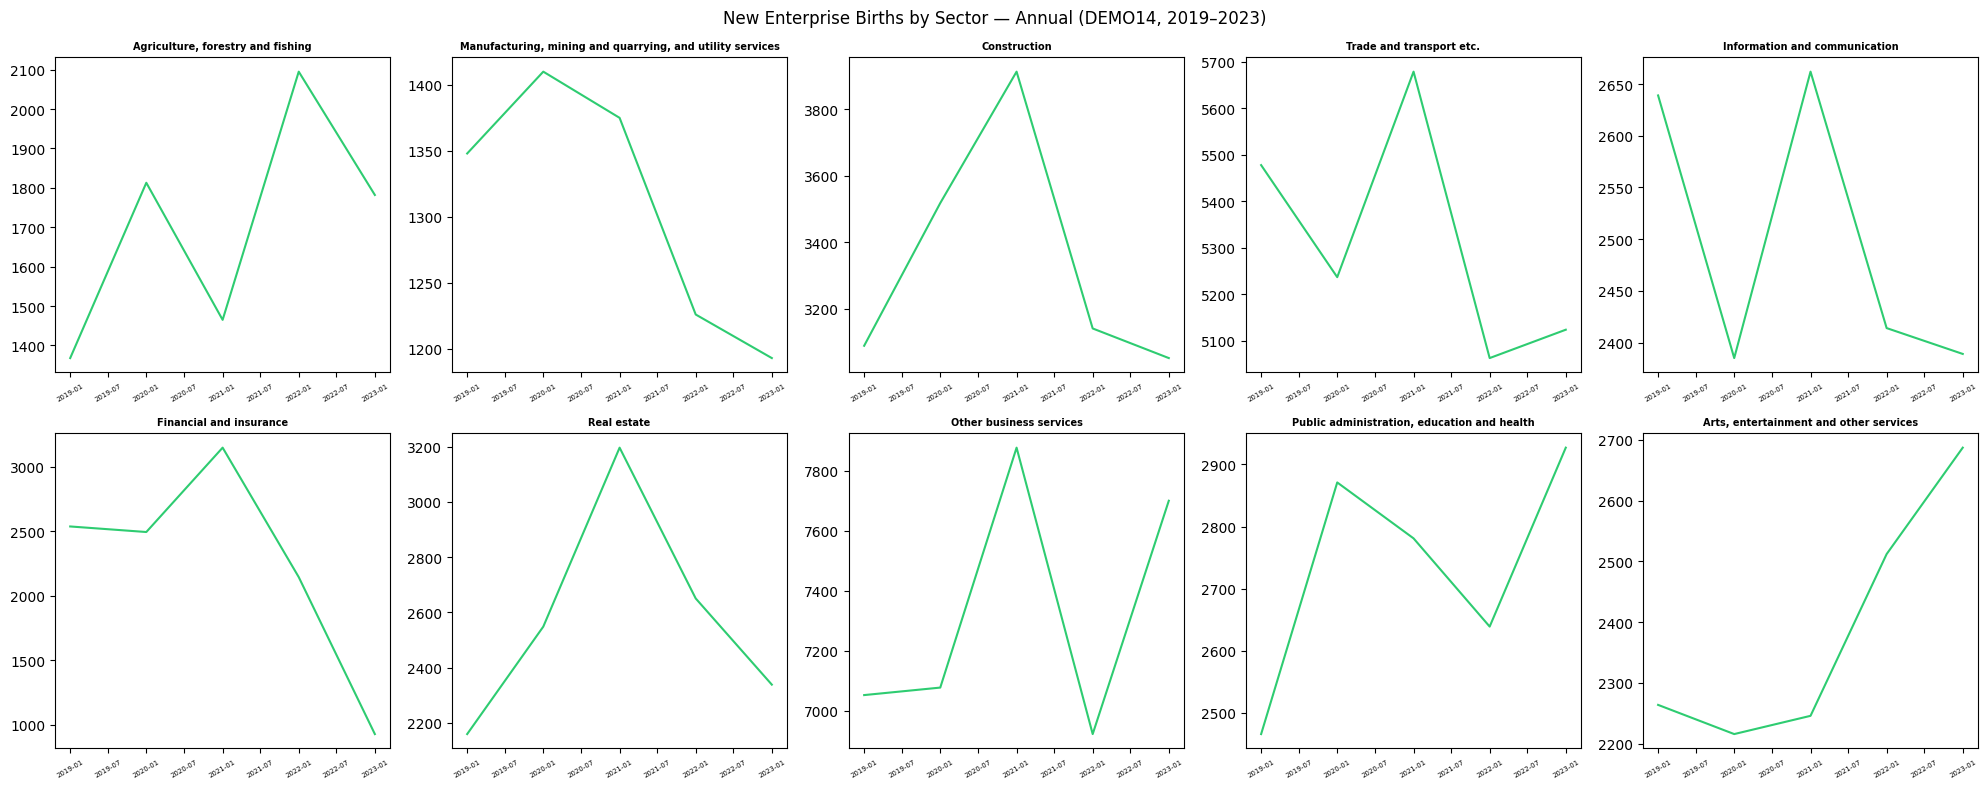

In [10]:
import matplotlib.pyplot as plt

# Pull exact sector names directly from the DEMO14 API metadata
info = client.get_table_info('DEMO14')
branch_var = next(v for v in info['variables'] if v['id'] == 'BRANCHEDB0710')
sector_names = {
    v['id']: v['text'].split(' ', 1)[1] if ' ' in v['text'] else v['text']
    for v in branch_var['values']
    if v['id'] not in ('TOT', '11')  # exclude total and "Activity not stated"
}
print("Sector mapping loaded:")
for k, v in sector_names.items():
    print(f"  {k}: {v}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8), sharey=False)
axes = axes.flatten()

sectors = df_new['branche'].unique()[:10] if 'branche' in df_new.columns else []
for i, sector in enumerate(sectors):
    s = df_new[df_new['branche'] == sector].set_index('period')['new_enterprises']
    label = sector_names.get(str(sector), str(sector))
    axes[i].plot(s.index, s.values, color='#2ecc71', linewidth=1.5)
    axes[i].set_title(label, fontsize=7, fontweight='bold')
    axes[i].tick_params(axis='x', labelsize=5, rotation=30)

plt.suptitle('New Enterprise Births by Sector — Annual (DEMO14, 2019–2023)', fontsize=12)
plt.tight_layout()
plt.savefig('../artifacts/reports/fig_new_enterprises_by_sector.png', dpi=120)
plt.show()

## 1.4 Save raw artifacts
Both datasets are saved as timestamped CSVs in `artifacts/raw/`.
The pipeline keeps a `_latest.csv` version for downstream steps,
and a timestamped version for full reproducibility.


In [11]:
# Save raw artifacts
path_bankrupt = save_raw(df_bankrupt, 'bankruptcies', raw_dir='../artifacts/raw')
path_new = save_raw(df_new, 'new_enterprises', raw_dir='../artifacts/raw')

import os
files = os.listdir('../artifacts/raw')
print("Artifacts in raw/:")
for f in sorted(files):
    size = os.path.getsize(f'../artifacts/raw/{f}')
    print(f"  {f:50s}  {size/1024:.1f} KB")


2026-04-16 17:19:34,183 [INFO] Saved → ../artifacts/raw/bankruptcies_20260416_171934.csv
2026-04-16 17:19:34,185 [INFO] Saved → ../artifacts/raw/new_enterprises_20260416_171934.csv


Artifacts in raw/:
  bankruptcies_20260416_132247.csv                    41.1 KB
  bankruptcies_20260416_132345.csv                    41.1 KB
  bankruptcies_20260416_171934.csv                    41.1 KB
  bankruptcies_latest.csv                             41.1 KB
  new_enterprises_20260416_132247.csv                 1.0 KB
  new_enterprises_20260416_132345.csv                 1.0 KB
  new_enterprises_20260416_171934.csv                 1.0 KB
  new_enterprises_latest.csv                          1.0 KB
